# Práctica 1: Aprendizaje Automático
**Predicción de Subscripsción a un Producto Bancario**

* **Autores:** Jaime del Campo Montaña & David Alexander Torres Paillacho
* **NIA's:** 100495957 100522187

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, FunctionTransformer, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree


RANDOM_STATE = 100522187
np.random.seed(RANDOM_STATE)


In [45]:
dataframe = pd.read_pickle('bank_15.pkl')
#muestro las primeras filas del dataframe --> comprobación
display(dataframe.head())

#flas, columnas, tipos de datos y valores nulos
print("\nInformación del dataframe")
dataframe.info()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes



Información del dataframe
<class 'pandas.DataFrame'>
Index: 11000 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11000 non-null  int64 
 1   job        10920 non-null  object
 2   marital    11000 non-null  object
 3   education  10744 non-null  object
 4   default    11000 non-null  object
 5   balance    11000 non-null  int64 
 6   housing    11000 non-null  object
 7   loan       11000 non-null  object
 8   contact    11000 non-null  object
 9   day        11000 non-null  int64 
 10  month      11000 non-null  object
 11  duration   11000 non-null  int64 
 12  campaign   11000 non-null  int64 
 13  pdays      11000 non-null  int64 
 14  previous   11000 non-null  int64 
 15  poutcome   11000 non-null  object
 16  deposit    11000 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.5+ MB


A continuación analizaremos los datos del dataset


In [46]:
#número de instancias y variables
print(f"número de instancias (filas): {dataframe.shape[0]}")
print(f"número de variables (columnas): {dataframe.shape[1]}")
#comprobación de valores nulos
print("\nvalores null por columna")
nulos = dataframe.isnull().sum()
print(nulos[nulos > 0])

número de instancias (filas): 11000
número de variables (columnas): 17

valores null por columna
job           80
education    256
dtype: int64


In [47]:
#variables categóricas > 10
categorical_columans = dataframe.select_dtypes(include=['object']).columns
print("\nCardinalidad de variables categóricas")
for columna in categorical_columans:
    val_unicos = dataframe[columna].nunique()
    if val_unicos > 10:
        print(f"'{columna}'tiene alta cardinal              idad: {val_unicos} valores únicos")
    else:
        print(f"'{columna}':{val_unicos} valores únicos")

#columnas constantes
print("\ncolumnas constantes")
constant_columnas = [columna for columna in dataframe.columns if dataframe[columna].nunique() <= 1]
if len(constant_columnas) == 0:
    print("no hay columnas constantes.")
else:
    print(f"columnas constantes encontradas: {constant_columnas}")


Cardinalidad de variables categóricas
'job'tiene alta cardinal              idad: 12 valores únicos
'marital':3 valores únicos
'education':4 valores únicos
'default':2 valores únicos
'housing':2 valores únicos
'loan':2 valores únicos
'contact':3 valores únicos
'month'tiene alta cardinal              idad: 12 valores únicos
'poutcome':4 valores únicos
'deposit':2 valores únicos

columnas constantes
no hay columnas constantes.


In [48]:
#comprobar desbalanceo de la variable objetivo
print("Distribución de la variable objetivo (deposit):")
print(dataframe['deposit'].value_counts(normalize=True))

#análisis de pdays
print("\nEstadísticas de pdays:")
print(dataframe['pdays'].describe())


Distribución de la variable objetivo (deposit):
deposit
no     0.525455
yes    0.474545
Name: proportion, dtype: float64

Estadísticas de pdays:
count    11000.000000
mean        51.308636
std        108.782842
min         -1.000000
25%         -1.000000
50%         -1.000000
75%         20.250000
max        854.000000
Name: pdays, dtype: float64


In [49]:
#separar X e y
X = dataframe.drop('deposit', axis=1)
y = dataframe['deposit']

#división Holdout (2/3 train, 1/3 test) según instrucciones
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.33, random_state=RANDOM_STATE, stratify=y
)

print(f"Tamaño entrenamiento: {X_train.shape[0]}")
print(f"Tamaño test: {X_test.shape[0]}")

Tamaño entrenamiento: 7370
Tamaño test: 3630


In [50]:
cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring_metric = 'roc_auc'

In [51]:
#separamos columnas por tipo
#variables numéricas estándar 
num_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'previous']

#variables categóricas con nulos
cat_cols_con_nulos = ['job', 'education']

#resto
cat_cols = ['marital', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome'] 

#pdays
pdays_col = ['pdays']


#transformacion de pdays
def transform_pdays(X):
    #transform_pdays recibe un array 2D, pero nosotros queremos trabajar con un array 1D para hacer las transformaciones más fácilmente.    
   
    pdays_valores = np.array(X).flatten() #aseguramos que es un array 1D
    
    no_previo = (pdays_valores == -1).astype(int) #1 si no hay contacto previo, 0 si sí lo hubo
    dias_validos = np.where(pdays_valores == -1, 0, pdays_valores) #reemplazamos -1 por 0 para que no afecte numéricamente
    return np.column_stack((no_previo, dias_validos))

def get_pdays_names(transformer, feature_names):
    return ['pdays_no_previo', 'pdays_dias_validos']

pdays_transformer = FunctionTransformer(
    transform_pdays, 
    validate=False,
    feature_names_out=get_pdays_names
)




#pipeline para las categóricas con nulos: Imputación + OneHotEncoding
cat_nulos_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

#pipeline para el resto , solo el OneHotEncoding
cat_pipe = Pipeline(steps=[
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])


num_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')) #por si hubiese algun valor nulo
])


#unimos todo en ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipe, num_cols),
        ('cat_nulos', cat_nulos_pipe, cat_cols_con_nulos),
        ('cat_normales', cat_pipe, cat_cols),
        ('pdays_custom', pdays_transformer, pdays_col)
    ],
    remainder='passthrough' 
)   

In [52]:


#convertimos la variable objetivo a números 
y_train_num = y_train.map({'no': 0, 'yes': 1})
y_test_num = y_test.map({'no': 0, 'yes': 1})

#usamos StandardScaler como punto de partida para el escalado
knn_default_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier()) 
])

#medimos tiempo de entrenamiento directo
print("Entrenando KNN con hiperparámetros por defecto...")
inicio = time.time()
knn_default_pipe.fit(X_train, y_train_num)
final = time.time()
tiempo_default = final - inicio

#evaluamos usando la validación cruzada 
cv_scores_default = cross_val_score(knn_default_pipe, X_train, y_train_num, cv=cv_inner, scoring=scoring_metric, n_jobs=-1)

print(f"Tiempo de entrenamiento (Default): {tiempo_default:.4f} segundos")
print(f"Puntuación media ({scoring_metric}) en validación interna: {cv_scores_default.mean():.4f}")

Entrenando KNN con hiperparámetros por defecto...
Tiempo de entrenamiento (Default): 0.0489 segundos
Puntuación media (roc_auc) en validación interna: 0.8133


In [53]:
#creamos el pipeline
knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

#definimos la cuadricula de parametros
param_grid_knn = {
    'scaler': [StandardScaler(), MinMaxScaler(), RobustScaler()],
    'knn__n_neighbors': [3, 5, 7, 9, 11, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35]
}

#configuramos la busqueda
grid_knn = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=param_grid_knn,
    scoring=scoring_metric, #roc_auc
    cv=cv_inner,            
    n_jobs=-1               
)

print("Entrenando y evaluando modelos KNN... espera un momento.")
#inicimaos cronómetro
inicio = time.time()
grid_knn.fit(X_train, y_train_num)
#finalizamos cronómetro
final = time.time()
tiempo = final - inicio
print("\nEntrenamiento completado")
print(f"El tiempo de ejucción del Gridsearch es {tiempo:.4f} segundos")
print(f"Mejor combinación encontrada: {grid_knn.best_params_}")
print(f"Mejor puntuación ({scoring_metric}) en validación interna: {grid_knn.best_score_:.4f}")

Entrenando y evaluando modelos KNN... espera un momento.

Entrenamiento completado
El tiempo de ejucción del Gridsearch es 6.5490 segundos
Mejor combinación encontrada: {'knn__n_neighbors': 25, 'scaler': RobustScaler()}
Mejor puntuación (roc_auc) en validación interna: 0.8791


### 4.2 Árboles de Decisión 

A continuación, vamos a evaluar un modelo basado en Árboles de Decisión. Al igual que con KNN, primero entrenaremos un modelo con sus hiperparámetros por defecto para establecer una línea base y mediremos su tiempo de ejecución. 


In [54]:
#creamos el pipeline del árbol 
tree_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('tree', DecisionTreeClassifier(random_state=RANDOM_STATE))])


print("Arbol por defecto")
inicio = time.time()
tree_pipeline.fit(X_train, y_train_num)
final = time.time()
tiempo = final - inicio

#evaluamos el inner del modelo por defecto
cv_scores_def_tree = cross_val_score(tree_pipeline, X_train, y_train_num, cv=cv_inner, scoring=scoring_metric, n_jobs=-1)

print(f"Tiempo de entrenamiento: {tiempo:.4f} segundos")
print(f"Puntuación media ({scoring_metric}) en validación interna: {cv_scores_def_tree.mean():.4f}\n")

Arbol por defecto
Tiempo de entrenamiento: 0.1910 segundos
Puntuación media (roc_auc) en validación interna: 0.7858



#### Optimización de Hiperparámetros (HPO) para el Árbol

Para intentar mejorar el rendimiento base y evitar el sobreajuste, vamos a realizar una búsqueda en rejilla (GridSearchCV). Optimizaremos los siguientes hiperparámetros:
* max_depth:  controla la profundidad máxima del árbol.
* min_samples_split: número mínimo de muestras necesarias para dividir un nodo interno.
* criterion:  función para medir la calidad de una división.

In [55]:
# Cuadrícula de hiperparámetros
param_grid_tree = {
    'tree__max_depth': [3, 5, 7, 10, None],
    'tree__min_samples_split': [2, 5, 10, 20],
    'tree__criterion': ['gini', 'entropy']
}

grid_tree = GridSearchCV(
    estimator=tree_pipeline,
    param_grid=param_grid_tree,
    scoring=scoring_metric, 
    cv=cv_inner,
    n_jobs=-1
)

start_time_hpo = time.time()
grid_tree.fit(X_train, y_train_num)
end_time_hpo = time.time()
tiempo_hpo_tree = end_time_hpo - start_time_hpo

print("¡Entrenamiento completado!")
print(f"Tiempo de ejecución del GridSearch: {tiempo_hpo_tree:.4f} segundos")
print(f"Mejor combinación: {grid_tree.best_params_}")
print(f"Mejor puntuación ({scoring_metric}) en validación interna: {grid_tree.best_score_:.4f}")

¡Entrenamiento completado!
Tiempo de ejecución del GridSearch: 4.2981 segundos
Mejor combinación: {'tree__criterion': 'gini', 'tree__max_depth': 7, 'tree__min_samples_split': 20}
Mejor puntuación (roc_auc) en validación interna: 0.8793


#### Interpretabilidad y Extracción de Conocimiento 

Una de las grandes ventajas de los árboles de decisión frente a métodos como KNN es que son modelos de "caja blanca". Para extraer conocimiento de negocio y entender qué variables son las más determinantes para que un cliente suscriba un depósito, vamos a entrenar un árbol poco profundo (*shallow tree* con max_depth=3) y lo visualizaremos.

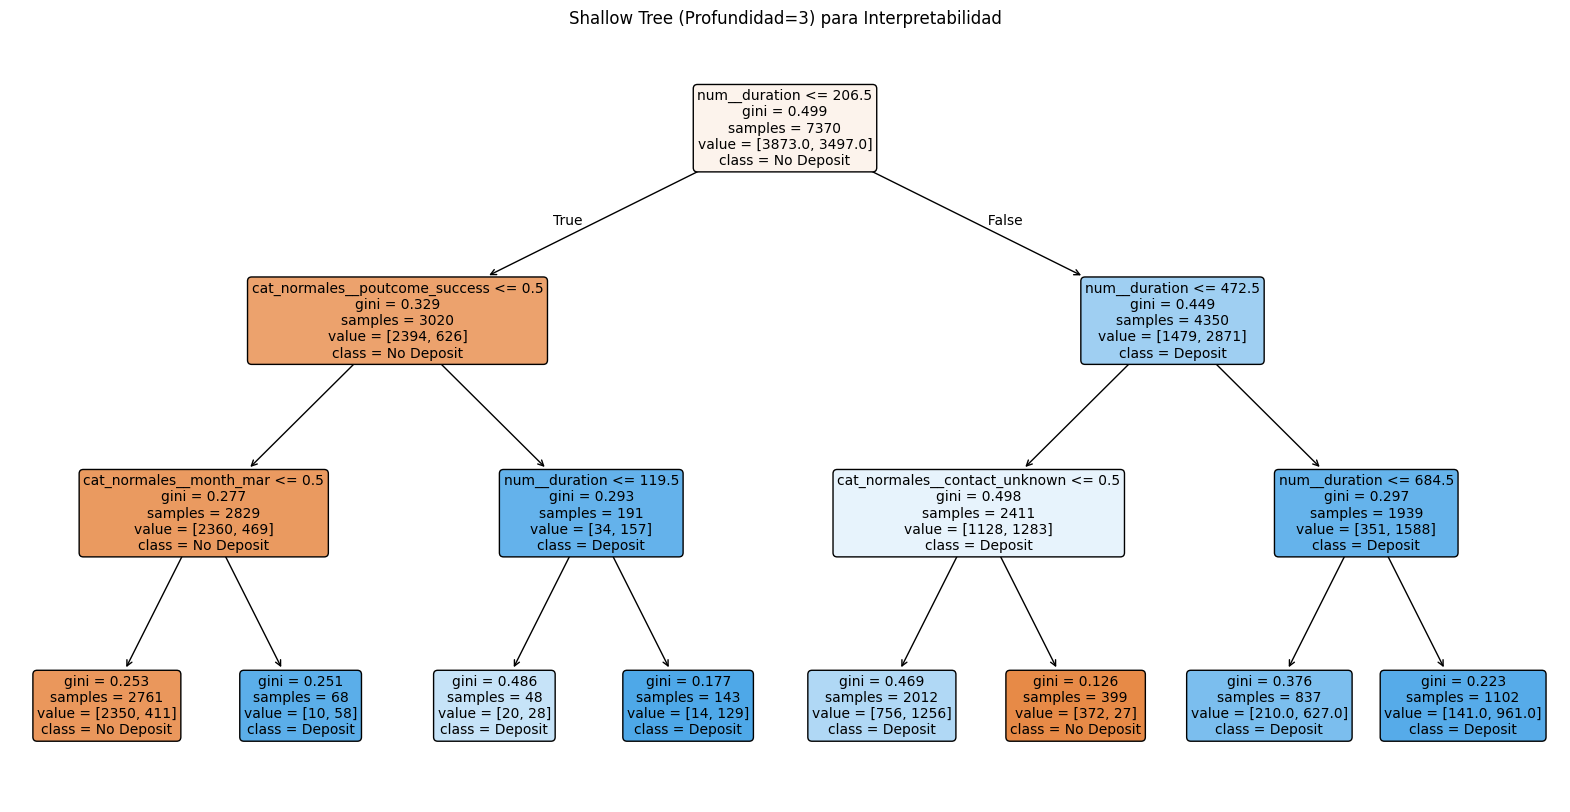

In [56]:
#entrenamos un árbol de profundidad 3 como ejemplo
shallow_tree_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('tree', DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE))
])
shallow_tree_pipe.fit(X_train, y_train_num)

#extraemos el modelo y los nombres de las columnas
modelo_arbol = shallow_tree_pipe.named_steps['tree']
nombres_features = shallow_tree_pipe.named_steps['preprocessor'].get_feature_names_out()

#dibujamos el árbol
plt.figure(figsize=(20, 10))
plot_tree(modelo_arbol, feature_names=nombres_features, 
          class_names=['No Deposit', 'Deposit'], filled=True, 
          rounded=True, fontsize=10)
plt.title("Shallow Tree (Profundidad=3) para Interpretabilidad")
plt.show()

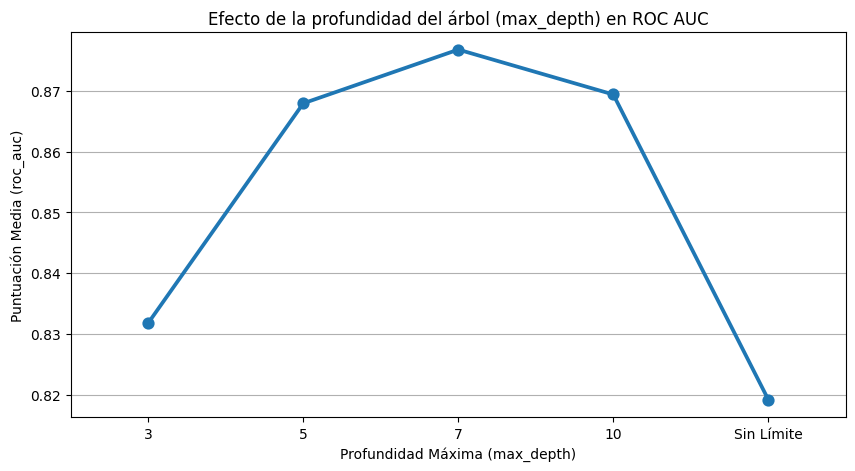

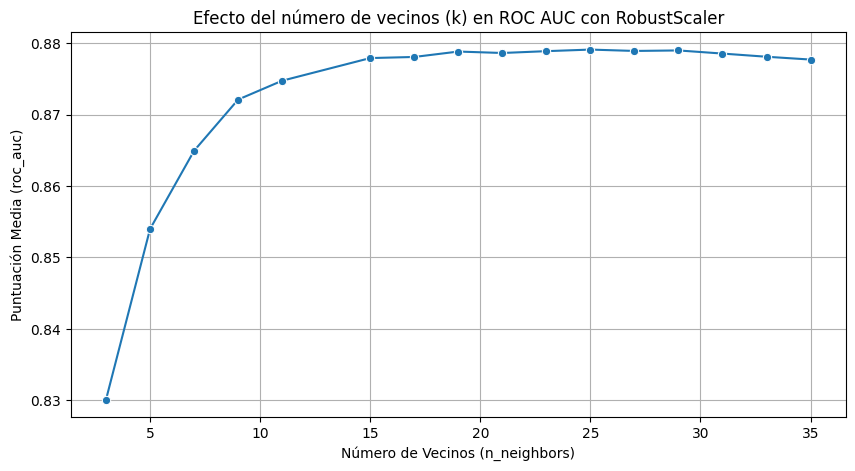

In [ ]:
import seaborn as sns


resultados_tree = pd.DataFrame(grid_tree.cv_results_)
#convertimos todo explícitamente a texto (string) para que no haya problemas
resultados_tree['param_tree__max_depth'] = resultados_tree['param_tree__max_depth'].fillna('Sin Límite').astype(str)

plt.figure(figsize=(10, 5))
#cambiamos lineplot por pointplot, que gestiona perfecto el texto y los números en el eje X
sns.pointplot(data=resultados_tree, x='param_tree__max_depth', y='mean_test_score', errorbar=None)
plt.title("Efecto de la profundidad del árbol (max_depth) en ROC AUC")
plt.xlabel("Profundidad Máxima (max_depth)")
plt.ylabel(f"Puntuación Media ({scoring_metric})")
plt.grid(True, axis='y')
plt.show()


resultados_knn = pd.DataFrame(grid_knn.cv_results_)
mejor_escalador_str = grid_knn.best_params_['scaler'].__class__.__name__
resultados_knn_filtrados = resultados_knn[resultados_knn['param_scaler'].astype(str).str.contains(mejor_escalador_str)]

plt.figure(figsize=(10, 5))

sns.lineplot(data=resultados_knn_filtrados, x='param_knn__n_neighbors', y='mean_test_score', marker='o')
plt.title(f"Efecto del número de vecinos (k) en ROC AUC con {mejor_escalador_str}")
plt.xlabel("Número de Vecinos (n_neighbors)")
plt.ylabel(f"Puntuación Media ({scoring_metric})")
plt.grid(True)
plt.show()

Conclusiones aqui.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import time


#regresión Logística 
logreg_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', RobustScaler()),
    ('logreg', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])


logreg_l1_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', RobustScaler()),
    ('logreg_l1', LogisticRegression(penalty='l1', solver='liblinear', max_iter=2000, random_state=RANDOM_STATE))
])

#support Vector Machine (SVM)
svm_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', RobustScaler()),
    ('svm', SVC(random_state=RANDOM_STATE))
])


def evaluar_modelo_avanzado(pipeline, nombre):
    print(f"Entrenando {nombre}...")
    inicio = time.time()
    pipeline.fit(X_train, y_train_num)
    tiempo_fit = time.time() - inicio
    
    #validación cruzada
    cv_scores = cross_val_score(pipeline, X_train, y_train_num, cv=cv_inner, scoring=scoring_metric, n_jobs=-1)
    
    print(f"--> Tiempo: {tiempo_fit:.4f}s | Puntuación Media ({scoring_metric}): {cv_scores.mean():.4f}\n")


print("--- EVALUACIÓN POR DEFECTO MÉTODOS AVANZADOS ---\n")
evaluar_modelo_avanzado(logreg_pipe, "Regresión Logística (Default/L2)")
evaluar_modelo_avanzado(logreg_l1_pipe, "Regresión Logística (L1)")
evaluar_modelo_avanzado(svm_pipe, "Support Vector Machine (SVM)")

--- EVALUACIÓN POR DEFECTO MÉTODOS AVANZADOS ---

Entrenando Regresión Logística (Default/L2)...
--> Tiempo: 0.2689s | Puntuación Media (roc_auc): 0.9047

Entrenando Regresión Logística (L1)...


C:\Users\Jaime\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Jaime\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


--> Tiempo: 0.3174s | Puntuación Media (roc_auc): 0.9052

Entrenando Support Vector Machine (SVM)...
--> Tiempo: 1.2277s | Puntuación Media (roc_auc): 0.9030



In [ ]:
import warnings
warnings.filterwarnings('ignore') 
#optimizamos el parámetro 'C' 
param_grid_logreg = {
    'logreg__C': [0.01, 0.1, 1, 10, 100]
}

grid_logreg = GridSearchCV(
    estimator=logreg_pipe,
    param_grid=param_grid_logreg,
    scoring=scoring_metric,
    cv=cv_inner,
    n_jobs=-1
)

print("Iniciando GridSearch para Regresión Logística...")
inicio = time.time()
grid_logreg.fit(X_train, y_train_num)
tiempo_logreg_hpo = time.time() - inicio

print(f"Mejor LogReg (C={grid_logreg.best_params_['logreg__C']}) -> ROC AUC: {grid_logreg.best_score_:.4f} (Tiempo: {tiempo_logreg_hpo:.4f}s)\n")


#el SVM es lento, así que probamos una cuadrícula pequeñita para no eternizarnos
param_grid_svm = {
    'svm__C': [0.1, 1, 10],
    'svm__kernel': ['linear', 'rbf']
}

grid_svm = GridSearchCV(
    estimator=svm_pipe,
    param_grid=param_grid_svm,
    scoring=scoring_metric,
    cv=cv_inner,
    n_jobs=-1
)

print("Iniciando GridSearch para SVM (esto puede tardar unos minutos)...")
inicio = time.time()
grid_svm.fit(X_train, y_train_num)
tiempo_svm_hpo = time.time() - inicio

print(f"Mejor SVM ({grid_svm.best_params_}) -> ROC AUC: {grid_svm.best_score_:.4f} (Tiempo: {tiempo_svm_hpo:.4f}s)")

Iniciando GridSearch para Regresión Logística...
Mejor LogReg (C=100) -> ROC AUC: 0.9054 (Tiempo: 1.1935s)

Iniciando GridSearch para SVM (esto puede tardar unos minutos)...
Mejor SVM ({'svm__C': 10, 'svm__kernel': 'rbf'}) -> ROC AUC: 0.9103 (Tiempo: 30.7642s)


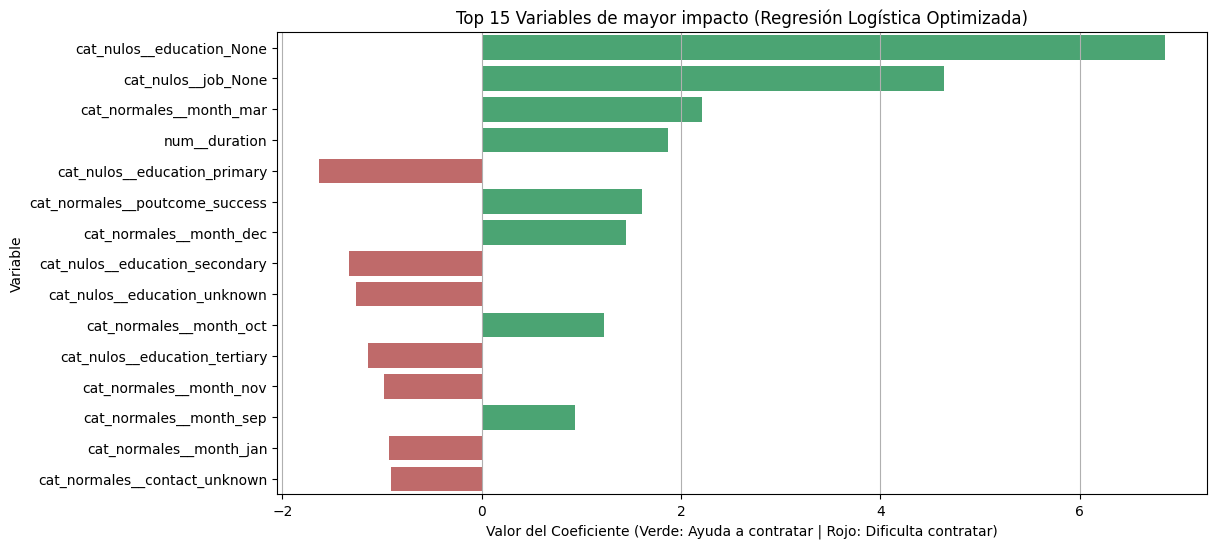

In [ ]:
#extraemos el mejor modelo de Regresión Logística para analizar la importancia de variables
mejor_logreg_pipe = grid_logreg.best_estimator_
modelo_logreg = mejor_logreg_pipe.named_steps['logreg']
preprocesador_logreg = mejor_logreg_pipe.named_steps['preprocessor']

# 2. Obtenemos los nombres de las variables transformadas y sus coeficientes
nombres_variables = preprocesador_logreg.get_feature_names_out()
coeficientes = modelo_logreg.coef_[0]

#creamos un DataFrame para ordenar la información
importancia_df = pd.DataFrame({
    'Variable': nombres_variables,
    'Coeficiente': coeficientes,
    'Importancia_Absoluta': np.abs(coeficientes) 
})

#ordenamos de mayor a menor impacto
importancia_df = importancia_df.sort_values(by='Importancia_Absoluta', ascending=False)
top_15_variables = importancia_df.head(15)

# 4. Visualizamos
plt.figure(figsize=(12, 6))
#pintamos de verde si el coeficiente es positivo y rojo si es negativo
sns.barplot(
    data=top_15_variables, 
    x='Coeficiente', 
    y='Variable', 
    hue=top_15_variables['Coeficiente'] > 0, 
    palette={True: 'mediumseagreen', False: 'indianred'}, 
    legend=False
)
plt.title("Top 15 Variables de mayor impacto (Regresión Logística Optimizada)")
plt.xlabel("Valor del Coeficiente (Verde: Ayuda a contratar | Rojo: Dificulta contratar)")
plt.ylabel("Variable")
plt.grid(True, axis='x')
plt.show()